# Qwen3.5-4B LoRA 微调及 SwanLab 可视化记录

本教程使用 LoRA 方法在「甄嬛」角色对话数据集上微调 **Qwen3.5-4B**，并使用 **SwanLab** 记录训练过程。

## 环境配置

> Qwen3.5 采用 Gated Delta Network（线性注意力）+ 全注意力的混合架构，需要 `transformers>=4.57`。

```bash
# 换清华镜像源
pip config set global.index-url https://pypi.tuna.tsinghua.edu.cn/simple

# 核心依赖
pip install "transformers>=4.57" accelerate datasets peft swanlab modelscope

# 可选但强烈推荐：为线性注意力安装加速算子（不安装也能运行，会自动回退到 PyTorch 实现）
pip install flash-linear-attention causal-conv1d
```


# 导入环境

In [ ]:
import json
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
)
from peft import LoraConfig, TaskType, get_peft_model
import swanlab
from swanlab.integration.transformers import SwanLabCallback


# 读取数据集

本教程使用甄嬛对话数据集（Alpaca 格式：`instruction / input / output`）。

In [ ]:
# 读取甄嬛对话数据集
dataset_path = "/root/autodl-tmp/huanhuan.json"   # 注意修改为你的数据集路径
with open(dataset_path, "r", encoding="utf-8") as f:
    data = json.load(f)

ds = Dataset.from_list(data)
ds

In [ ]:
ds[:3]

# 认识 Qwen3.5 的 Chat Template

Qwen3.5 默认开启思考模式（`enable_thinking=True`）。对于「角色扮演」任务，我们通常**关闭思考模式**（`enable_thinking=False`），让模型直接给出符合角色设定的回答。

In [ ]:
model_id = "/root/autodl-tmp/Qwen/Qwen3.5-4B"   # 注意修改为你的模型路径
tokenizer = AutoTokenizer.from_pretrained(model_id)
print("eos:", tokenizer.eos_token, tokenizer.eos_token_id)
print("pad:", tokenizer.pad_token, tokenizer.pad_token_id)

In [ ]:
messages = [
    {"role": "system", "content": "现在你要扮演皇帝身边的女人--甄嬛"},
    {"role": "user", "content": "你父亲是谁？"},
    {"role": "assistant", "content": "家父是大理寺少卿甄远道。"},
]

text = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=False, enable_thinking=False
)
print(text)

# 处理数据集

对每条样本，分别 tokenize「前缀（system + user）」和「完整对话」，再用 **token 级别切片**精确得到 `response`。
`labels` 中只有回答部分参与 loss 计算，其余部分被置为 `-100` 屏蔽。

> `transformers` 新版中 `apply_chat_template(tokenize=True)` 默认返回 `BatchEncoding`，传入 `return_dict=False` 可直接得到 token id 列表。

In [ ]:
def process_func(example):
    MAX_LENGTH = 1024  # 最大序列长度
    SYS = "现在你要扮演皇帝身边的女人--甄嬛"

    messages = [
        {"role": "system", "content": SYS},
        {"role": "user", "content": example["instruction"] + example["input"]},
        {"role": "assistant", "content": example["output"]},
    ]
    # 前缀部分（system + user，带 generation prompt），不计算 loss
    prompt_ids = tokenizer.apply_chat_template(
        messages[:2], tokenize=True, add_generation_prompt=True,
        enable_thinking=False, return_dict=False,
    )
    # 完整对话（含 assistant 回答）
    full_ids = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=False,
        enable_thinking=False, return_dict=False,
    )
    # token 级别切片得到 response
    response_ids = full_ids[len(prompt_ids):]

    input_ids = prompt_ids + response_ids
    labels = [-100] * len(prompt_ids) + response_ids
    attention_mask = [1] * len(input_ids)

    if len(input_ids) > MAX_LENGTH:  # 超长截断
        input_ids = input_ids[:MAX_LENGTH]
        attention_mask = attention_mask[:MAX_LENGTH]
        labels = labels[:MAX_LENGTH]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

In [ ]:
tokenized_id = ds.map(process_func, remove_columns=ds.column_names)
tokenized_id

In [ ]:
# 查看完整输入
print(tokenizer.decode(tokenized_id[0]["input_ids"]))

In [ ]:
# 查看 labels（过滤掉 -100 后即为模型需要学习的回答）
print(tokenizer.decode(list(filter(lambda x: x != -100, tokenized_id[0]["labels"]))))

# 加载模型

Qwen3.5-4B 是多模态模型（`Qwen3_5ForConditionalGeneration`）。只用文本能力时，`AutoModelForCausalLM` 会自动加载文本语言模型 `Qwen3_5ForCausalLM`（不含视觉塔，显存更省）。

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="auto",
)
# 开启梯度检查点时需要调用该方法
model.enable_input_require_grads()
model.dtype

# LoRA 配置

**关于 Qwen3.5 的混合架构**：32 层中，每 4 层有 3 层是线性注意力（`linear_attn`），1 层是全注意力（`self_attn`）。
- 全注意力层：`q_proj / k_proj / v_proj / o_proj`
- 线性注意力层：`in_proj_qkv / in_proj_z / in_proj_a / in_proj_b / out_proj`
- 每一层都有 MLP：`gate_proj / up_proj / down_proj`

下面的 `target_modules` 覆盖了所有全注意力层与**每一层的 MLP**，已能让每一层都参与 LoRA 训练。若想更充分地适配线性注意力层，可把 `in_proj_qkv`、`in_proj_z`、`out_proj` 一并加入。

In [ ]:
config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    inference_mode=False,   # 训练模式
    r=8,                    # Lora 秩
    lora_alpha=32,          # Lora alpha，缩放系数 = 32/8 = 4
    lora_dropout=0.1,       # Dropout 比例
)
config

In [ ]:
model = get_peft_model(model, config)
model.print_trainable_parameters()

# 配置训练参数

In [ ]:
args = TrainingArguments(
    output_dir="./output/Qwen3_5_4B_LoRA",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    logging_steps=10,
    num_train_epochs=3,
    save_steps=100,
    learning_rate=1e-4,
    save_on_each_node=True,
    gradient_checkpointing=True,
    report_to="none",
)

# SwanLab 简介

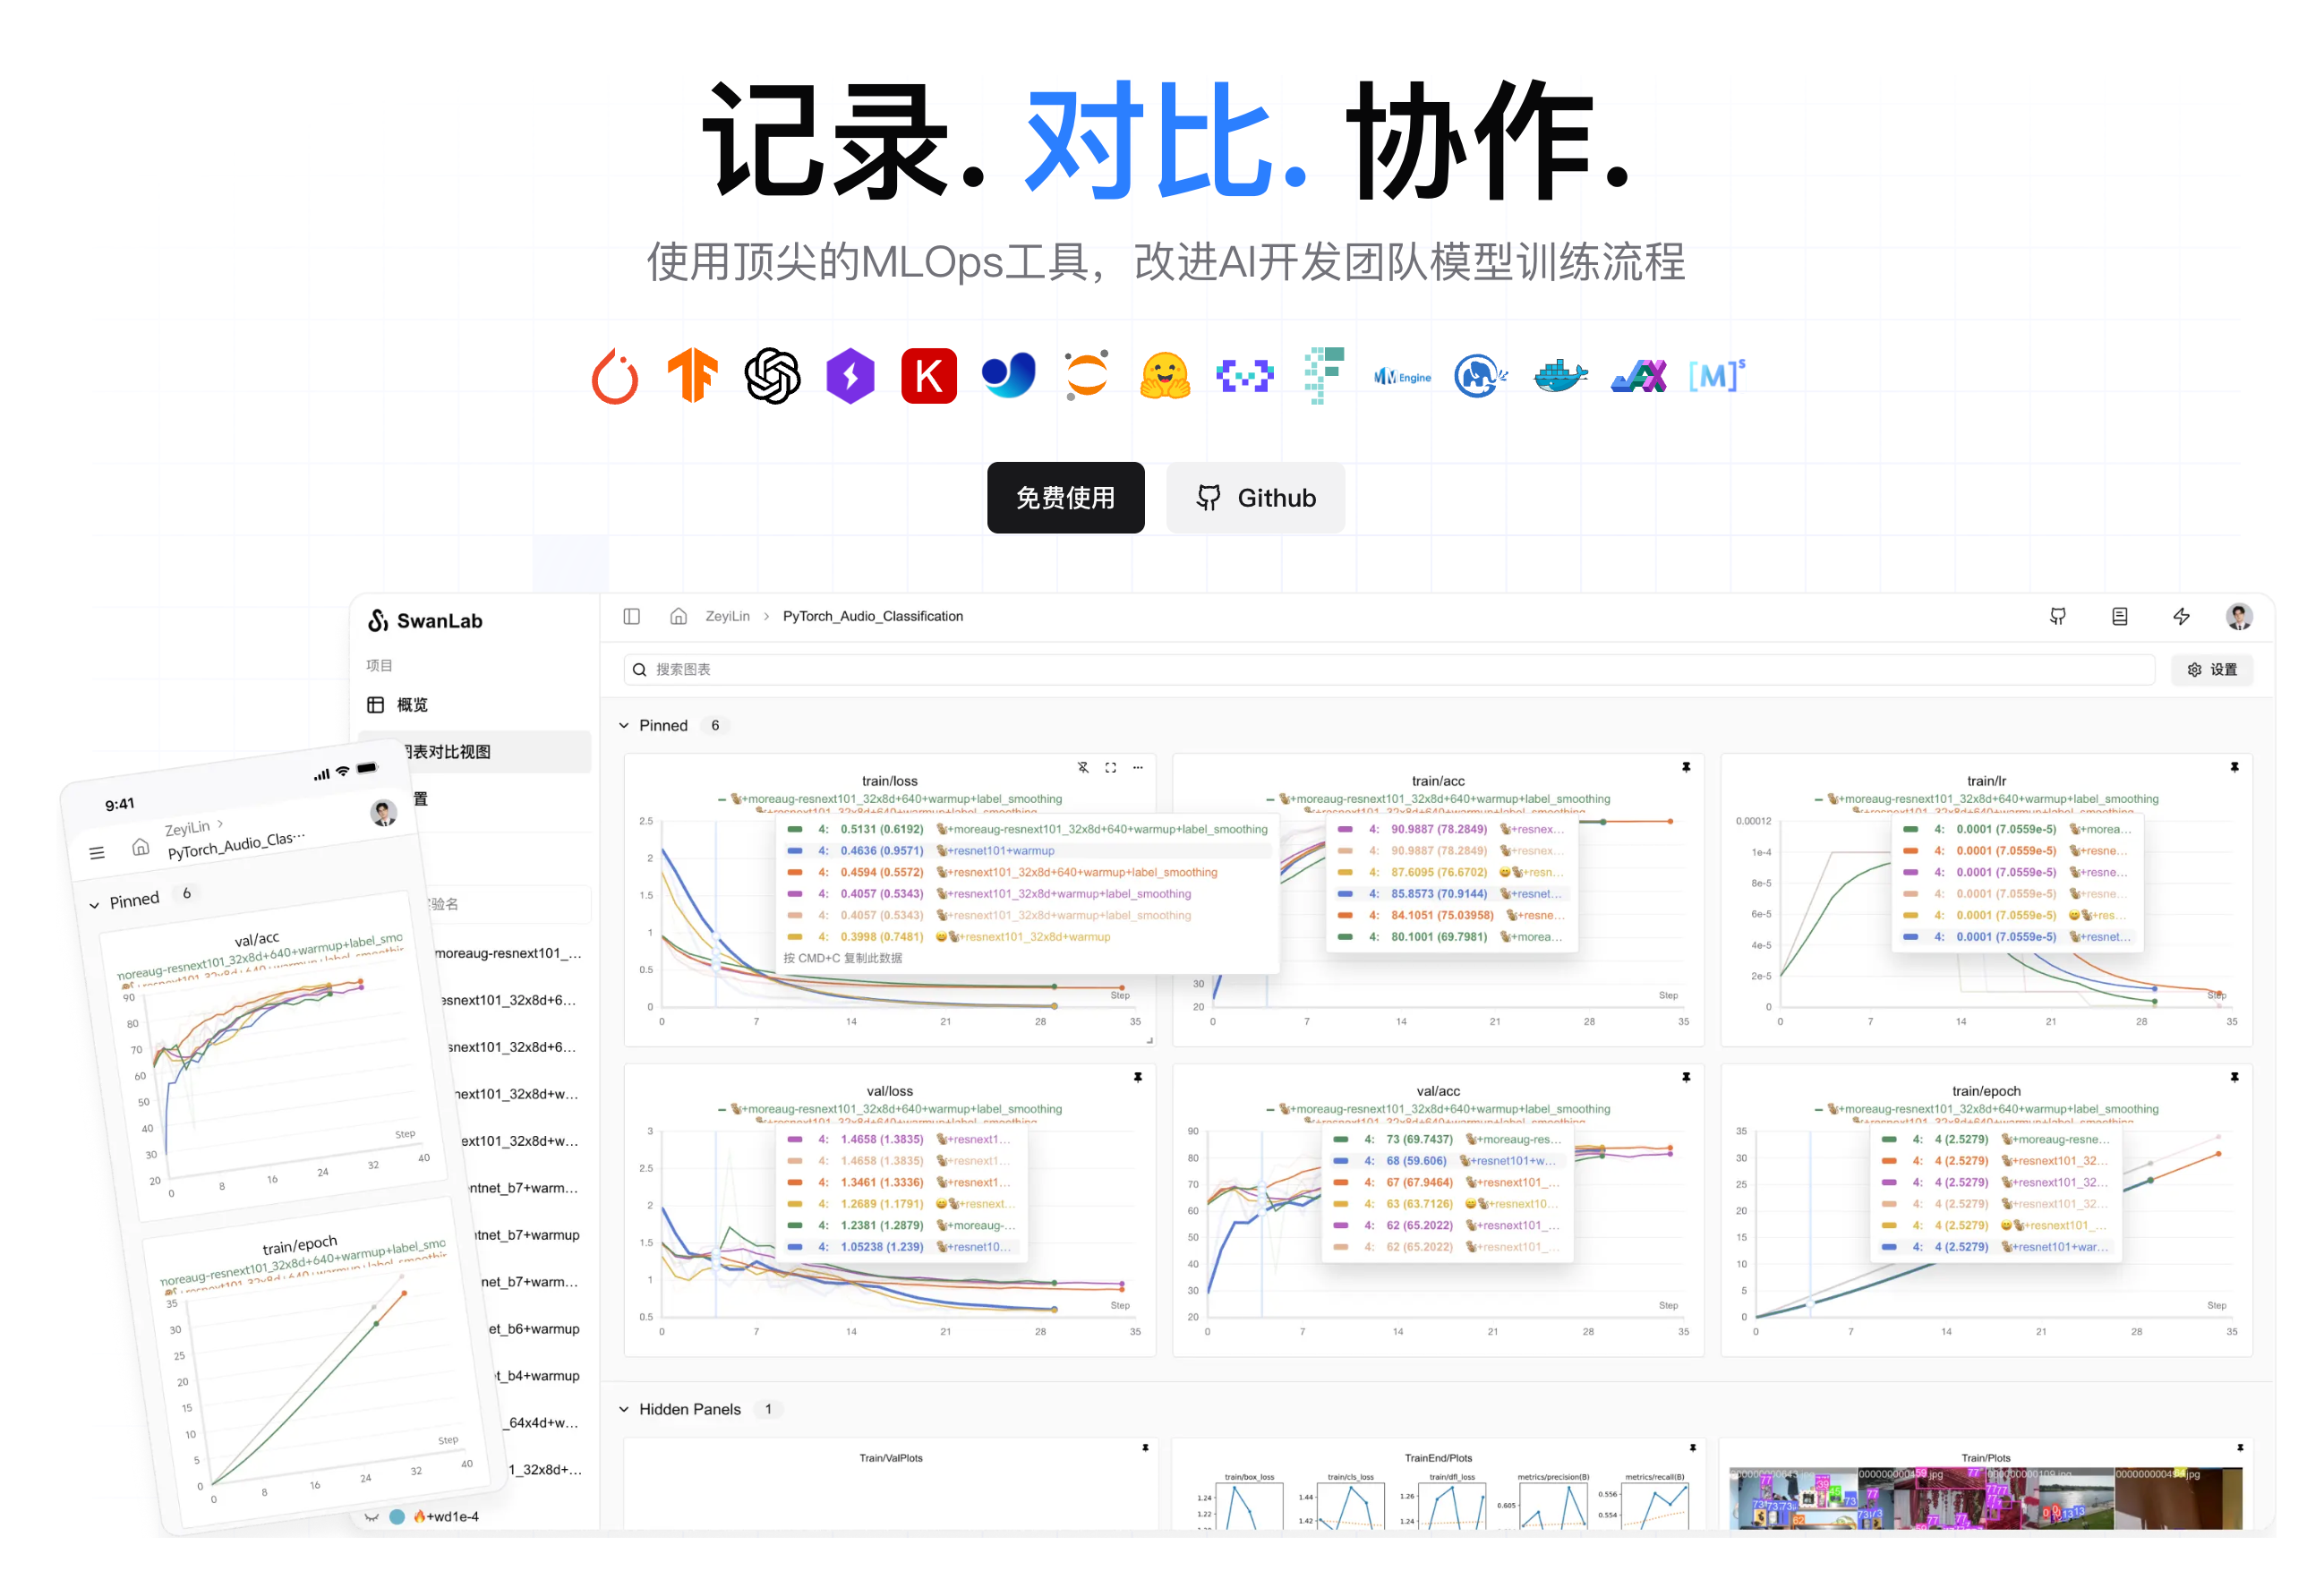

[SwanLab](https://github.com/swanhubx/swanlab) 是一个开源的模型训练记录工具，提供训练可视化、自动日志记录、超参数记录、实验对比、多人协同等功能。

建议先在 [SwanLab 官网](https://swanlab.cn/) 注册账号，初始化时选择 `(2) Use an existing SwanLab account` 并使用 private API Key 登录。

In [ ]:
# 实例化 SwanLabCallback
# 首次使用会提示登录，输入你在 SwanLab 官网获取的 API Key
swanlab_callback = SwanLabCallback(
    project="Qwen3.5-Lora",
    experiment_name="Qwen3.5-4B-LoRA",
)

# 训练

In [ ]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_id,
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True),
    callbacks=[swanlab_callback],
)

trainer.train()

# 加载 LoRA 权重推理

得到 checkpoint 后，加载基础模型并挂载 LoRA 权重进行推理。

In [ ]:
from peft import PeftModel

# 基础模型路径 & 训练得到的 LoRA 权重路径（按实际 checkpoint 编号修改）
lora_path = "./output/Qwen3_5_4B_LoRA/checkpoint-702"

# 加载基础模型
base_model = AutoModelForCausalLM.from_pretrained(
    model_id, dtype=torch.bfloat16, device_map="auto"
)
# 挂载 LoRA 权重
model = PeftModel.from_pretrained(base_model, model_id=lora_path)
model.eval()

In [ ]:
prompt = "你是谁？"
messages = [
    {"role": "system", "content": "现在你要扮演皇帝身边的女人--甄嬛"},
    {"role": "user", "content": prompt},
]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    enable_thinking=False,       # 关闭思考模式，直接输出角色回答
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device)

gen_kwargs = {"max_new_tokens": 128, "do_sample": True, "top_p": 0.8, "temperature": 0.7}
with torch.no_grad():
    outputs = model.generate(**inputs, **gen_kwargs)
outputs = outputs[:, inputs["input_ids"].shape[1]:]
print(tokenizer.decode(outputs[0], skip_special_tokens=True))